# 01 — Análise Exploratória de Dados (EDA)

**Objetivo:** Caracterizar o desbalanceamento extremo (578:1) e identificar, via testes estatísticos (D'Agostino para normalidade, Mann-Whitney com tamanho de efeito), quais features separam fraude de transação legítima — estabelecendo PR-AUC como a métrica adequada.

---

**Roteiro:**

1. Setup
2. Carregamento de Dados
3. Desbalanceamento do target e estrutura do dataset
4. Verificação de normalidade
5. Testes estatísticos: Mann-Whitney com rank biserial
6. Visualizações Comparativas de Amount e Time (Features anonimizadas)
7. Fechamento


### Etapa 1 - Setup

In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from scipy.stats import mannwhitneyu, normaltest

from src.config import CAMINHOS, CONFIG
from src.viz_config import aplicar_tema_seaborn, PALETTE, CORES

DADOS_BRUTOS = CAMINHOS.dados_raw / CAMINHOS.dados_brutos
DADOS_PRO    = CAMINHOS.dados_processed
FIGURAS_DIR  = CAMINHOS.figures
RANDOM_STATE = CONFIG["dados"]["random_state"]
TARGET       = CONFIG["dados"]["target_col"]

DADOS_PRO.mkdir(parents=True, exist_ok=True)
FIGURAS_DIR.mkdir(parents=True, exist_ok=True)

aplicar_tema_seaborn()
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

print("\n✅ Setup configurado!")

print(f"\nFIGURAS: {FIGURAS_DIR}")
print(f"DADOS BRUTOS: {DADOS_BRUTOS}")
print(f"DADOS PROCESSADOS: {DADOS_PRO}")


✅ Setup configurado!

FIGURAS: C:\Users\jas_t\Repo\Portfolios\credit_card_fraud\reports\figures
DADOS BRUTOS: C:\Users\jas_t\Repo\Portfolios\credit_card_fraud\data\raw\creditcard.zip
DADOS PROCESSADOS: C:\Users\jas_t\Repo\Portfolios\credit_card_fraud\data\processed


### Etapa 2 - Carregamento de Dados

In [2]:
df = pd.read_csv(DADOS_BRUTOS)

print(f"Dataset carregado: {df.shape[0]:,} linhas × {df.shape[1]} colunas\n")

df.head()

Dataset carregado: 284,807 linhas × 31 colunas



,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### Etapa 3 - Desbalanceamento do target e estrutura do dataset

In [3]:
df. info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [4]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,2.239053e-15,1.673327e-15,-1.247012e-15,8.190001e-16,1.207294e-15,4.887456e-15,1.437716e-15,-3.772171e-16,9.564149e-16,1.039917e-15,6.406204e-16,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,1.088850e+00,1.020713e+00,9.992014e-01,9.952742e-01,9.585956e-01,9.153160e-01,8.762529e-01,8.493371e-01,8.381762e-01,8.140405e-01,7.709250e-01,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,-2.458826e+01,-4.797473e+00,-1.868371e+01,-5.791881e+00,-1.921433e+01,-4.498945e+00,-1.412985e+01,-2.516280e+01,-9.498746e+00,-7.213527e+00,-5.449772e+01,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,-5.354257e-01,-7.624942e-01,-4.055715e-01,-6.485393e-01,-4.255740e-01,-5.828843e-01,-4.680368e-01,-4.837483e-01,-4.988498e-01,-4.562989e-01,-2.117214e-01,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,-9.291738e-02,-3.275735e-02,1.400326e-01,-1.356806e-02,5.060132e-02,4.807155e-02,6.641332e-02,-6.567575e-02,-3.636312e-03,3.734823e-03,-6.248109e-02,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,4.539234e-01,7.395934e-01,6.182380e-01,6.625050e-01,4.931498e-01,6.488208e-01,5.232963e-01,3.996750e-01,5.008067e-01,4.589494e-01,1.330408e-01,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,2.374514e+01,1.201891e+01,7.848392e+00,7.126883e+00,1.052677e+01,8.877742e+00,1.731511e+01,9.253526e+00,5.041069e+00,5.591971e+00,3.942090e+01,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [5]:
print("═" * 60)
print("ESTRUTURA")
print("═" * 60)

print(f"Linhas x Colunas : {df.shape[0]:,} x {df.shape[1]:,}")
print(f"Nulos no total   : {df.isnull().sum().sum()}")
print(f"Duplicatas       : {df.duplicated().sum():,}")
print(f"Tipos            : {df.dtypes.value_counts().to_dict()}")

════════════════════════════════════════════════════════════
ESTRUTURA
════════════════════════════════════════════════════════════
Linhas x Colunas : 284,807 x 31
Nulos no total   : 0
Duplicatas       : 1,081
Tipos            : {dtype('float64'): 30, dtype('int64'): 1}


Vamos verificar o desbalanceamento do nosso target

In [6]:
cont = df[TARGET].value_counts()
pct = df[TARGET].value_counts(normalize=True) * 100

n_fraude = int(cont.get(1, 0))
n_legit = int(cont.get(0, 0))

ratio = n_legit / n_fraude

In [7]:
print("═" * 60)
print("DESBALANCEAMENTO DO TARGET (Class)")
print("═" * 60)

print(f"   Legítimas (0): {n_legit:>9,}  ({pct[0]:.3f}%)")
print(f"   Fraudes   (1): {n_fraude:>9,}  ({pct[1]:.3f}%)")
print(f"   Razão        : {ratio:.0f}:1  (1 fraude a cada {ratio:.0f} transações)")

════════════════════════════════════════════════════════════
DESBALANCEAMENTO DO TARGET (Class)
════════════════════════════════════════════════════════════
   Legítimas (0):   284,315  (99.827%)
   Fraudes   (1):       492  (0.173%)
   Razão        : 578:1  (1 fraude a cada 578 transações)


A distribuição das classes revela um **desbalanceamento extremo**, com uma proporção aproximada de **578 transações legítimas para cada transação fraudulenta**.

Esse cenário torna métricas tradicionais, como **Accuracy**, pouco informativas, pois um modelo pode apresentar elevada acurácia simplesmente prevendo a classe majoritária. Por esse motivo, a avaliação do desempenho será baseada principalmente em métricas mais adequadas para problemas desbalanceados, como **Precision-Recall AUC (PR-AUC)**, que fornece uma visão mais fiel da capacidade do modelo em identificar fraudes.

Para evidenciar visualmente esse desbalanceamento, foi construída uma distribuição das classes utilizando **escala logarítmica no eixo Y**. Sem essa transformação, a quantidade reduzida de casos de fraude faria com que sua barra praticamente desaparecesse no gráfico, dificultando a interpretação da magnitude da diferença entre as classes.

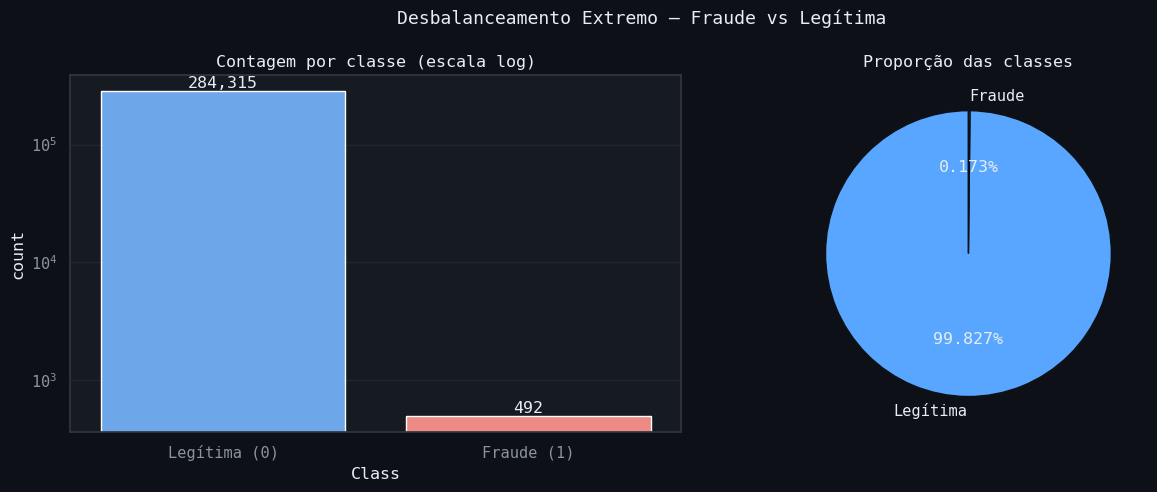

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.countplot(
    data=df, x=TARGET, hue=TARGET,
    palette=[PALETTE[0], PALETTE[1]],
    legend=False, ax=axes[0]
)
axes[0].set_xticks([0, 1])
axes[0].set_yscale("log")
axes[0].set_title("Contagem por classe (escala log)")
axes[0].set_xticklabels(["Legítima (0)", "Fraude (1)"])
for i, v in enumerate(cont.values):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom", color=CORES["texto"])

axes[1].pie(
    [n_legit, n_fraude], labels=["Legítima", "Fraude"],
    colors=[PALETTE[0], PALETTE[1]], autopct="%1.3f%%",
    startangle=90, textprops={"color": CORES["texto"]},
    wedgeprops={"edgecolor": CORES["fundo"]}
)
axes[1].set_title("Proporção das classes")

fig.suptitle("Desbalanceamento Extremo — Fraude vs Legítima", fontsize=13)
fig.tight_layout()
fig.savefig(FIGURAS_DIR / "nb01_desbalanceamento.png", dpi=120, bbox_inches="tight")
plt.show()

### Etapa 4 - Verificação de normalidade

Para avaliar o comportamento das variáveis numéricas, foram construídos histogramas de algumas **features selecionadas** do dataset.

Como o conjunto possui aproximadamente **30 variáveis**, visualizar todas simultaneamente poderia gerar excesso de informação e dificultar a interpretação dos padrões. Por isso, a análise foi concentrada em um subconjunto representativo de features, permitindo observar com mais clareza:

- a forma das distribuições;
- possíveis assimetrias;
- concentração de valores;
- presença de valores extremos;
- diferenças relevantes entre as variáveis analisadas.

Essa etapa auxilia na compreensão inicial dos dados e pode orientar decisões posteriores de pré-processamento, como normalização, padronização ou transformação das variáveis.

In [9]:
FEATURES = [c for c in df.columns if c != TARGET]
print(f"Features sem o TARGET: {FEATURES}")
print(f"\nQuantidade de features: {len(FEATURES)}")

Features sem o TARGET: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']

Quantidade de features: 30


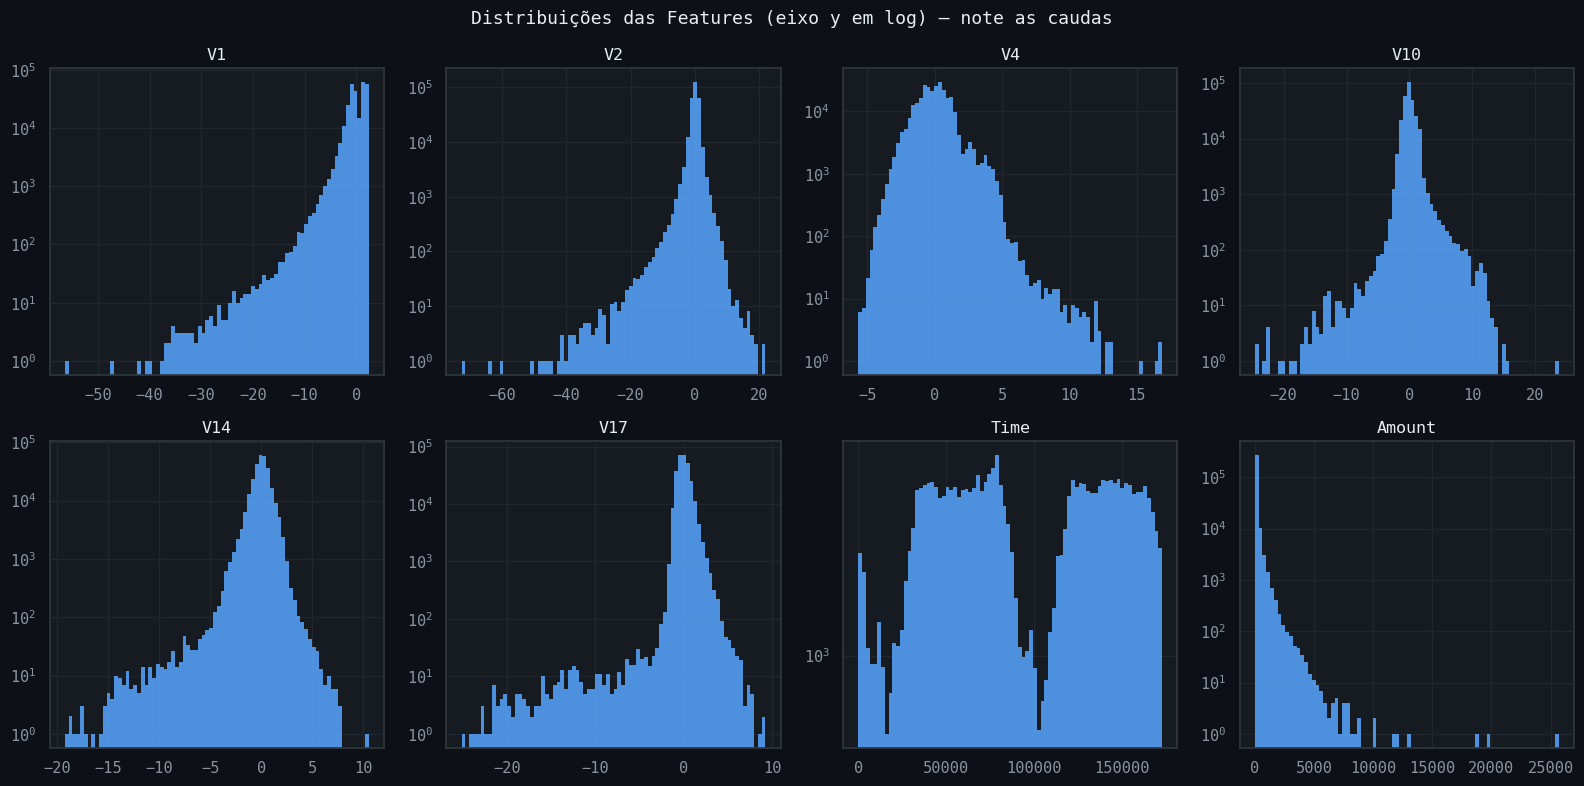

In [10]:
cols_mostrar = ["V1", "V2", "V4", "V10", "V14", "V17", "Time", "Amount"]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.flat, cols_mostrar):
    ax.hist(df[col], bins=80, color=PALETTE[0], edgecolor="none", alpha=0.85)
    ax.set_title(col)
    ax.set_yscale("log")
    
fig.suptitle("Distribuições das Features (eixo y em log) — note as caudas", fontsize=13)
fig.tight_layout()
fig.savefig(FIGURAS_DIR / "nb01_distribuicoes.png", dpi=120, bbox_inches="tight")
plt.show()

A análise dos histogramas evidencia que algumas variáveis apresentam distribuições assimétricas e com caudas longas, indicando desvio em relação à normalidade.

- As variáveis **V1, V2, V10, V14 e V17** apresentam distribuições com **caudas pesadas** e forte concentração de valores próximos ao centro.
- Em especial, **V2, V10, V14 e V17** exibem comportamento **leptocúrtico**, caracterizado por pico central elevado e maior presença de valores extremos.
- O uso de **escala logarítmica no eixo Y** foi importante para revelar essas caudas, que poderiam ficar pouco evidentes em escala linear.

A variável **Time** apresenta uma distribuição **bimodal**, com dois picos principais separados por um vale. Esse padrão é coerente com o fato de o dataset cobrir aproximadamente **dois dias de transações**, refletindo ciclos de maior e menor atividade ao longo do dia. Por esse motivo, o uso do `Time` em sua forma bruta tende a ter baixo poder preditivo direto, mas a variável pode ser transformada em uma representação mais informativa, como **hora do dia**.

A variável **Amount** segue um padrão típico de distribuição assimétrica à direita, semelhante a um comportamento exponencial decrescente. A maior parte das transações possui valores baixos, enquanto uma pequena quantidade apresenta valores muito elevados, formando uma cauda longa que chega a aproximadamente **25.000**. Essa assimetria extrema indica que transformações como `log1p` podem ser úteis em etapas posteriores de modelagem.

Para avaliar a aderência das variáveis à distribuição normal, foi aplicado o teste de normalidade **D'Agostino-Pearson** em todas as features numéricas.

A escolha desse teste foi motivada pelo tamanho do dataset, que possui aproximadamente **284 mil registros**. O teste de **Shapiro-Wilk**, embora bastante utilizado, não é recomendado nesse contexto devido à limitação prática para grandes amostras, especialmente acima de **5.000 observações**.

In [11]:
print("═" * 60)
print("TESTE DE NORMALIDADE (D'Agostino-Pearson, H0: normal)")
print("═" * 60)
nao_normais = 0
for col in FEATURES:
    stat, p = normaltest(df[col])
    if p < 0.05:
        nao_normais += 1
print(f"   Features testadas        : {len(FEATURES)}")
print(f"   Rejeitam normalidade (p<0.05): {nao_normais}")
print(f"   → {nao_normais}/{len(FEATURES)} features NÃO são normais")

════════════════════════════════════════════════════════════
TESTE DE NORMALIDADE (D'Agostino-Pearson, H0: normal)
════════════════════════════════════════════════════════════
   Features testadas        : 30
   Rejeitam normalidade (p<0.05): 30
   → 30/30 features NÃO são normais


**CONCLUSÃO:** usar testes NÃO-PARAMÉTRICOS (Mann-Whitney) para comparar fraude vs legítima — t-test seria inadequado.

### Etapa 5 - Testes estatísticos: Mann-Whitney com rank biserial

Para identificar quais features apresentam maior capacidade de separação entre transações **fraudulentas** e **legítimas**, foi aplicado o teste **Mann-Whitney U**.

A escolha desse teste é metodologicamente adequada, pois o teste de normalidade indicou que **30 de 30 features rejeitam a hipótese de normalidade** (*p* < 0,05). Nesse cenário, testes paramétricos como o **t-test** não seriam apropriados, uma vez que assumem distribuição aproximadamente normal dos dados.

Para cada variável, foram calculados:

- **p-valor**: indica se há diferença estatisticamente significativa entre os grupos;
- **tamanho de efeito rank-biserial**: mede a magnitude da separação entre fraudes e transações legítimas.

Como o dataset possui aproximadamente **284 mil registros**, a significância estatística tende a ocorrer com facilidade, fazendo com que muitas variáveis apresentem *p* < 0,001. Por isso, a análise não deve se basear apenas no p-valor.

Neste contexto, o principal critério de interpretação passa a ser o **tamanho de efeito**, pois ele permite avaliar quais features realmente apresentam maior poder discriminativo entre as classes.

In [12]:
legit  = df[df[TARGET] == 0]
fraude = df[df[TARGET] == 1]

resultados =[]

for col in FEATURES:
    stat, p = mannwhitneyu(legit[col], fraude[col], alternative="two-sided")

    n1, n2 = len(legit), len(fraude)
    rank_biserial = 1 - (2 * stat) / (n1 * n2)
    resultados.append({
        "feature": col,
        "p_valor": p,
        "efeito": abs(rank_biserial),
        "mediana_fraude": fraude[col].median(),
        "mediana_legit": legit[col].median(),
    })

res = pd.DataFrame(resultados).sort_values("efeito", ascending=False)

In [13]:
print("═" * 70)
print("MANN-WHITNEY U — poder discriminativo por feature (top 15)")
print("═" * 70)
print(f"   {'feature':<10}{'efeito':>9}{'p-valor':>12}"
      f"{'med.fraude':>13}{'med.legit':>12}")
print("   " + "─" * 56)


for _, r in res.head(15).iterrows():
    sig = "***" if r["p_valor"] < 0.001 else ("*" if r["p_valor"] < 0.05 else "ns")
    print(f"   {r['feature']:<10}{r['efeito']:>9.3f}{r['p_valor']:>12.1e}"
          f"{r['mediana_fraude']:>13.3f}{r['mediana_legit']:>12.3f}  {sig}")

print(f"\n   Features com efeito forte (>0.5): "
      f"{(res['efeito'] > 0.5).sum()}")
print(f"   Features sem significância (p>0.05): "
      f"{(res['p_valor'] > 0.05).sum()}")
print(f"   Efeito: 0 = sem separação, 1 = separação total\n")

══════════════════════════════════════════════════════════════════════
MANN-WHITNEY U — poder discriminativo por feature (top 15)
══════════════════════════════════════════════════════════════════════
   feature      efeito     p-valor   med.fraude   med.legit
   ────────────────────────────────────────────────────────
   V14           0.898    1.5e-260       -6.730       0.052  ***
   V4            0.877    3.6e-248        4.177      -0.022  ***
   V12           0.874    8.4e-247       -5.503       0.142  ***
   V11           0.836    4.9e-226        3.586      -0.035  ***
   V10           0.828    9.6e-222       -4.579      -0.092  ***
   V3            0.824    1.2e-219       -5.075       0.182  ***
   V2            0.710    1.7e-163        2.718       0.064  ***
   V16           0.694    1.8e-156       -3.550       0.067  ***
   V9            0.688    8.9e-154       -2.209      -0.050  ***
   V7            0.672    1.5e-146       -3.034       0.041  ***
   V17           0.616    9.2

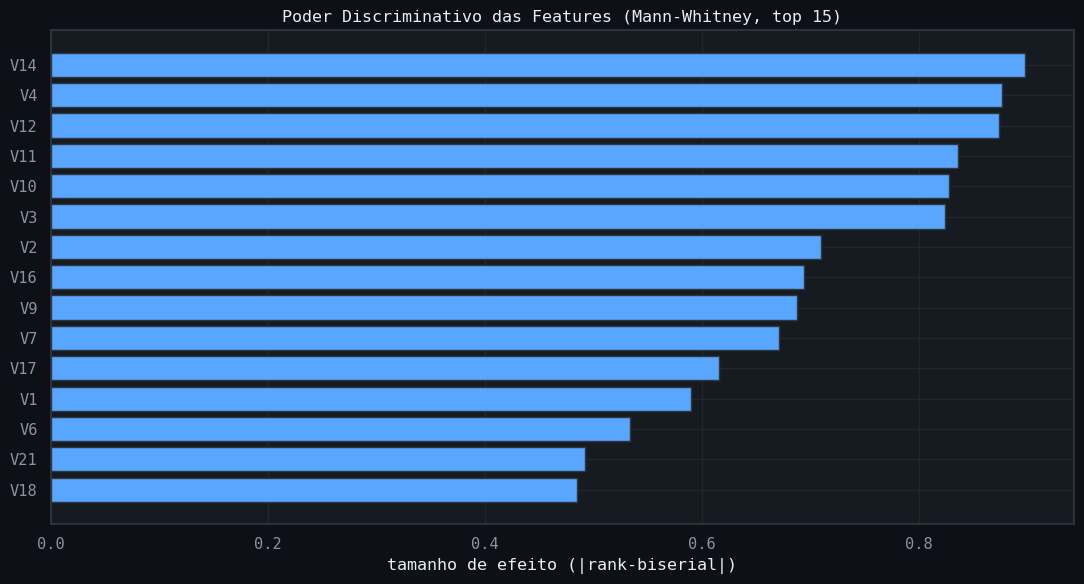

In [14]:
fig, ax = plt.subplots(figsize=(11, 6))

top = res.head(15).sort_values("efeito")

ax.barh(
    top["feature"], top["efeito"], color=PALETTE[0], edgecolor=CORES["borda"]
)

ax.set_xlabel("tamanho de efeito (|rank-biserial|)")
ax.set_title("Poder Discriminativo das Features (Mann-Whitney, top 15)")
fig.tight_layout()
fig.savefig(FIGURAS_DIR / "nb01_poder_discriminativo.png", dpi=120, bbox_inches="tight")
plt.show()

### Etapa 6 - Visualizações Comparativas de `Amount` e `Time` (Features anonimizadas)

Para complementar a análise exploratória, serão construídas visualizações específicas para as variáveis **Amount** e **Time**, considerando sua relação com a classe da transação.

As visualizações propostas são:

* **Distribuição de `Amount` por classe**: utilização de escala logarítmica para lidar com a forte assimetria e a cauda longa dos valores transacionais.
* **Boxplot de `Amount` por classe**: comparação da dispersão, mediana e presença de outliers entre transações legítimas e fraudulentas.
* **Distribuição de `Time` por classe**: análise do comportamento temporal das transações ao longo do período observado.
* **Estatísticas comparativas de `Amount`**: resumo quantitativo das diferenças entre as classes, incluindo medidas como média, mediana, quartis e valores extremos.

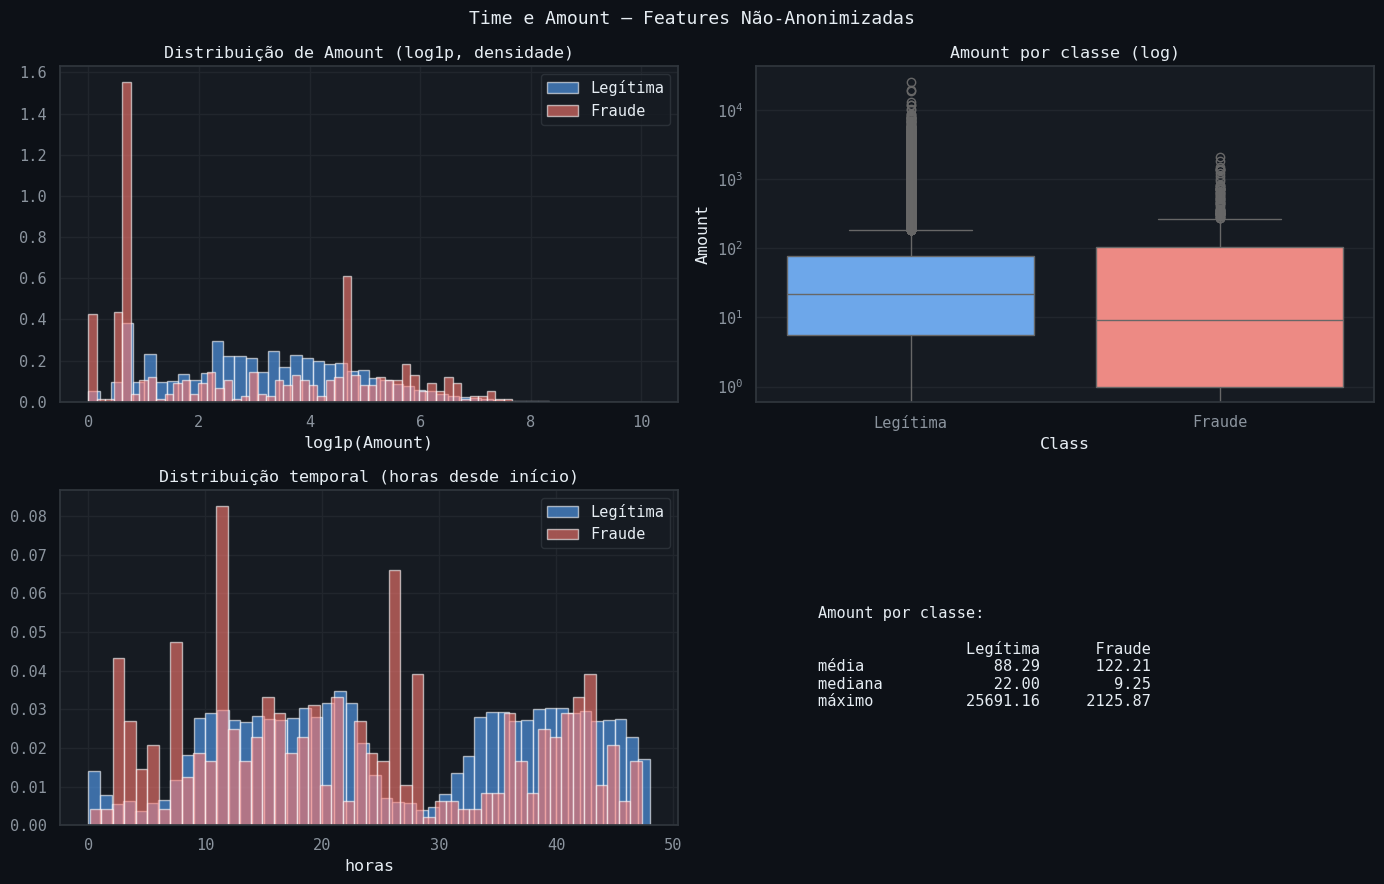

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for classe, cor, nome in [(0, PALETTE[0], "Legítima"), (1, PALETTE[1], "Fraude")]:
    dados = df[df[TARGET] == classe]["Amount"]
    axes[0, 0].hist(np.log1p(dados), bins=50, alpha=0.6, color=cor,
                    label=nome, density=True)
axes[0, 0].set_title("Distribuição de Amount (log1p, densidade)")
axes[0, 0].set_xlabel("log1p(Amount)")
axes[0, 0].legend()


sns.boxplot(data=df, x=TARGET, y="Amount", hue=TARGET,
            palette=[PALETTE[0], PALETTE[1]], legend=False, ax=axes[0, 1])
axes[0, 1].set_yscale("log")
axes[0, 1].set_title("Amount por classe (log)")
axes[0, 1].set_xticks([0, 1]); axes[0, 1].set_xticklabels(["Legítima", "Fraude"])


for classe, cor, nome in [(0, PALETTE[0], "Legítima"), (1, PALETTE[1], "Fraude")]:
    dados = df[df[TARGET] == classe]["Time"] / 3600   # segundos → horas
    axes[1, 0].hist(dados, bins=48, alpha=0.6, color=cor, label=nome, density=True)
axes[1, 0].set_title("Distribuição temporal (horas desde início)")
axes[1, 0].set_xlabel("horas")
axes[1, 0].legend()


stats_amount = df.groupby(TARGET)["Amount"].describe()[["mean", "50%", "max"]]
axes[1, 1].axis("off")
texto = "Amount por classe:\n\n"
texto += f"{'':12}{'Legítima':>12}{'Fraude':>12}\n"
texto += f"{'média':12}{stats_amount.loc[0,'mean']:>12.2f}{stats_amount.loc[1,'mean']:>12.2f}\n"
texto += f"{'mediana':12}{stats_amount.loc[0,'50%']:>12.2f}{stats_amount.loc[1,'50%']:>12.2f}\n"
texto += f"{'máximo':12}{stats_amount.loc[0,'max']:>12.2f}{stats_amount.loc[1,'max']:>12.2f}"
axes[1, 1].text(0.1, 0.5, texto, family="monospace", fontsize=11, color=CORES["texto"], va="center")

fig.suptitle("Time e Amount — Features Não-Anonimizadas", fontsize=13)
fig.tight_layout()
fig.savefig(FIGURAS_DIR / "nb01_time_amount.png", dpi=120, bbox_inches="tight")
plt.show()

Foi aplicado o teste Mann-Whitney U nas variáveis Amount e Time para avaliar se existem diferenças estatisticamente significativas entre transações legítimas e fraudulentas.

In [16]:
for col in ["Amount", "Time"]:
    stat, p = mannwhitneyu(fraude[col], legit[col], alternative="two-sided")
    print(f"   {col:8}: p={p:.2e}  "
          f"(med. fraude={fraude[col].median():.1f}, legit={legit[col].median():.1f})")

   Amount  : p=8.58e-06  (med. fraude=9.2, legit=22.0)
   Time    : p=4.39e-10  (med. fraude=75568.5, legit=84711.0)


A variável `Amount` revela um comportamento contraintuitivo: a mediana das fraudes é menor que a das transações legítimas.Esse padrão sugere que muitas fraudes ocorrem em valores baixos, possivelmente associadas a testes de cartão, em que pequenas compras são realizadas para verificar se o cartão comprometido ainda funciona.

A variável `Time` também apresenta diferenças entre as classes. Enquanto as transações legítimas seguem um padrão mais suave de atividade ao longo do tempo, as fraudes aparecem concentradas em alguns picos específicos. Esse comportamento sugere que fraudes podem ocorrer, possivelmente quando um cartão comprometido é utilizado várias vezes em sequência.

### Etapa 7 - Fechamento

**DATASET**
* 284.807 transações × 31 colunas · 0 nulos
* V1-V28 anonimizadas (PCA) + Time + Amount + Class
* Duplicatas a tratar no NB02

**DESBALANCEAMENTO EXTREMO**
* Fraude: 492 (0.173%) · Legítima: 284.315 (99.827%)
* Razão 578:1 → PR-AUC como métrica (não accuracy/ROC-AUC)

**NORMALIDADE**
* 30/30 features NÃO-normais (D'Agostino p<0.05)
* → testes não-paramétricos (Mann-Whitney) justificados

**PODER DISCRIMINATIVO (Mann-Whitney, tamanho de efeito)**
* Top: V14 (0.90), V4 (0.88), V12 (0.87), V11, V10, V3
* 13 features com efeito forte (>0.5) → classes SEPARÁVEIS
* Amount e Time: sinal fraco (efeito modesto)

**FEATURES CRUAS**
* Amount: fraude tem mediana MENOR (£9 vs £22) — testes de cartão
* Time: valor absoluto, não generaliza → descartar/transformar no NB02

**PRÓXIMO PASSO → NB02 (Feature Engineering)**
* Scaling do Amount (RobustScaler — robusto a outliers)
* Decidir Time (descartar vs feature cíclica)
* Remover duplicatas
* DECIDIR ESTRATÉGIA DE BALANCEAMENTO (a EDA sugere: classes
    separáveis + raras → SMOTE ou class_weight, testar no NB03)